Задание 1
подключите библиотеки
загрузите файл
выведите первые 10 строк


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('vgsales.csv')
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Задание 2
количество строк, количество столбцов, названия столбцов, типы данных, основные статистические характеристики


In [3]:
df.shape
df.columns.tolist()
df.dtypes
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Числовые столбцы: Rank, Year, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales

Текстовые столбцы: Name, Platform, Genre, Publisher

Столбцы с продажами: NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales

Задание 3

в каких столбцах имеются пропуски?

сколько пропущенных значений находится в каждом таком столбце?

какой столбец содержит больше всего пропусков?


In [4]:
df.isnull().sum()
df[df['Year'].isnull()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


Пропуски есть в столбцах: year, publisher

Year: 271 пропуск, Publisher: 58 пропусков

Больше всего пропусков в столбце year

Задание 4

проверьте размер

проверьте наличие пропусков


In [5]:
df_clean = df.dropna(subset=["Year"])
df_clean.shape
df_clean.isnull().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

Исходный датасет: 16600 строк

После удаления пропусков Year: 16327 строк

Пропуски в Year мешают анализу по годам, так как нельзя определить год выпуска игры

Задание 5

изучите категориальные признаки

●	жанры

●	количество жанров

●	платформы

●	количество платформ

●	издатели


In [6]:
df_clean['Genre'].nunique()
df_clean['Platform'].nunique()
df_clean['Publisher'].nunique()

576

Жанров: 12

Платформ: 31

Издателей: 576

Больше всего уникальных значений у Publisher

Задание 6
закрепим использование groupby()


In [7]:
genre_count = df_clean.groupby("Genre")["Name"].count().sort_values(ascending=False)
genre_count

Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: Name, dtype: int64

Задание 7 Продажи по жанрам

In [8]:
genre_sales = df_clean.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
genre_sales

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64

Задание 8 Самые продаваемые игры

In [9]:
top10 = df_clean.nlargest(10, 'Global_Sales')[["Rank", "Name", "Platform", "Genre", "Global_Sales"]]
top10

,Rank,Name,Platform,Genre,Global_Sales
0,1,Wii Sports,Wii,Sports,82.74
1,2,Super Mario Bros.,NES,Platform,40.24
2,3,Mario Kart Wii,Wii,Racing,35.82
3,4,Wii Sports Resort,Wii,Sports,33.00
4,5,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,6,Tetris,GB,Puzzle,30.26
6,7,New Super Mario Bros.,DS,Platform,30.01
7,8,Wii Play,Wii,Misc,29.02
8,9,New Super Mario Bros. Wii,Wii,Platform,28.62
9,10,Duck Hunt,NES,Shooter,28.31


Задание 9 Анализ платформ

In [10]:
platform_count = df_clean.groupby("Platform")["Name"].count().sort_values(ascending=False)
platform_count.head(10)
platform_sales = df_clean.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)
platform_sales

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
SNES     200.05
GC       197.14
XOne     141.06
2600      86.57
WiiU      81.86
PSV       61.63
SAT       33.59
GEN       28.36
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64

Задание 10 Визуализация продаж по жанрам

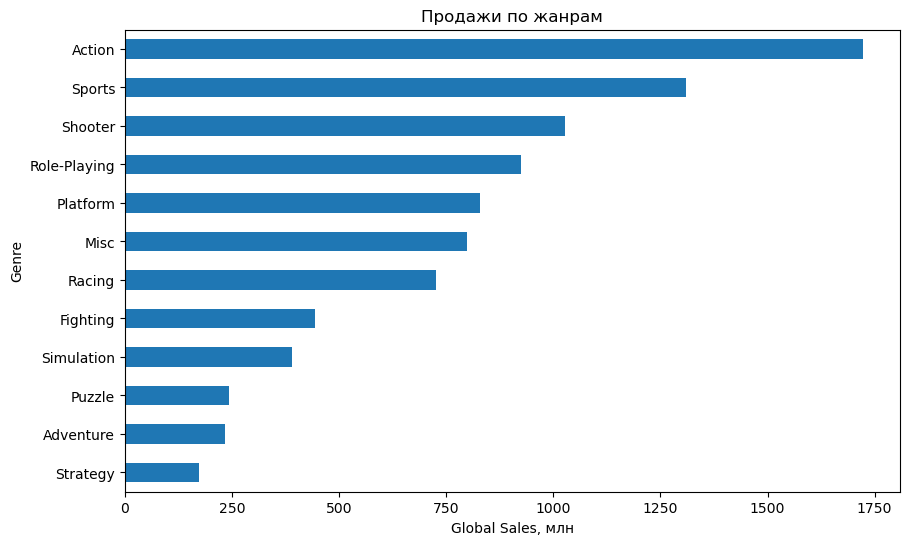

In [11]:
genre_sales.sort_values().plot(kind='barh', figsize=(10,6))
plt.xlabel('Global Sales, млн')
plt.title('Продажи по жанрам')
plt.show()

Наибольшие продажи: Action, Sports, Shooter

Наименьшие продажи: Puzzle, Strategy, Adventure

Разница между максимальным и минимальным значениями значительная (более чем в 10 раз)

Задание 11 Корреляция продаж

In [12]:
df_clean[['NA_Sales', 'Global_Sales']].corr()

,NA_Sales,Global_Sales
NA_Sales,1.000000,0.941268
Global_Sales,0.941268,1.000000


Значение положительное

Близко к 1 (≈0.94)

Да, можно говорить о выраженной положительной взаимосвязи

Задание 12 Диаграмма рассеяния

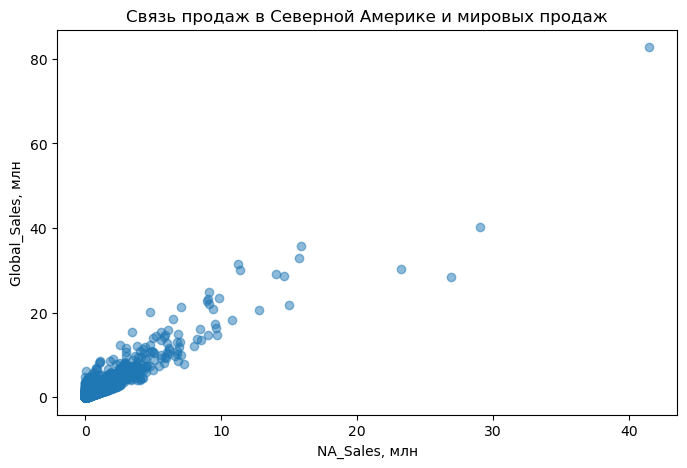

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["NA_Sales"], df_clean["Global_Sales"], alpha=0.5)
plt.xlabel("NA_Sales, млн")
plt.ylabel("Global_Sales, млн")
plt.title("Связь продаж в Северной Америке и мировых продаж")
plt.show()

Одна точка = одна игра

Наблюдается восходящая тенденция

Да, график соответствует результату корреляционного анализа

Задание 13 Корреляция между регионами

In [14]:
df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
NA_Sales,1.000000,0.768936,0.451285,0.634508
EU_Sales,0.768936,1.000000,0.436414,0.726266
JP_Sales,0.451285,0.436414,1.000000,0.290653
Other_Sales,0.634508,0.726266,0.290653,1.000000


Сильнее всего связаны NA_Sales и EU_Sales (≈0.62)

Вывод: продажи в Северной Америке и Европе имеют умеренную положительную связь; JP_Sales слабо связаны с другими регионами